# Notebook 05c — Gaussian Derivative Order Classification

**Goal:** Classify each RF as Lindeberg order m=0, m=1, or m=2 and assess the population-level breakdown.

## Theoretical background

Lindeberg (2025) describes V1 simple cells as *Gaussian derivative operators* of integer order m. The derivative order is a discrete typology that replaces the Gabor phase φ:

In the RF-aligned frame (u = along major axis θ, v = perpendicular):

$$G(u,v) = \exp\!\left(-\frac{u^2}{2\sigma_u^2} - \frac{v^2}{2\sigma_v^2}\right)$$

| Order | Model | Symmetry | Appearance |
|---|---|---|---|
| m=0 | $A \cdot G$ | even (cosine-like) | single lobe, blob |
| m=1 | $A \cdot \frac{u}{\sigma_u} \cdot G$ | odd (sine-like) | two opposite lobes |
| m=2 | $A \cdot \left(\frac{u^2}{\sigma_u^2}-1\right) \cdot G$ | even | central lobe + flanks |

All three models share the **same 7 parameters** (A, x₀, y₀, σ_u, σ_v, θ, b), so model selection reduces to comparing R² on the full signed RF map.

**Key difference from current nb05b pipeline:** m=1 and m=2 are fit to `rf_on − rf_off` (full signed map), *not* the dominant subfield. The zero-crossing between lobes is the discriminating signature — discarding it before fitting destroys the order information.

## Agenda
1. Sample neurons from the passing-QC set
2. Reconstruct RF maps with `reconstruct_rf()`
3. Run `classify_rf_order()` for each neuron
4. Inspect population distribution of m
5. Gallery: representative neurons per order
6. Check: does the m=0 assumption in nb05b systematically bias σ/κ for m≠0 neurons?
7. Implications for the main analysis

In [1]:
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import gaussian_filter
import os
import time

# --- AllenSDK ---
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

# --- Local module (ensure the updated sparse_noise.py is on the path) ---
sys.path.insert(0, str(Path('src/rf_analysis').resolve()))   # adjust if needed
from sparse_noise import (
    reconstruct_rf,
    fit_gaussian_derivative,          # existing m=0 pipeline
    classify_rf_order,                # NEW: multi-order classification
    fit_rf_by_order,                  # NEW: single-order fit on signed map
    gaussian_deriv_m0,
    gaussian_deriv_m1,
    gaussian_deriv_m2,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
warnings.filterwarnings('ignore', category=RuntimeWarning)
print('Imports OK')

Imports OK


In [2]:
# ---------------------------------------------------------------------------
# 1.  Paths — mirror nb05b Cell 2 exactly
# ---------------------------------------------------------------------------
import os
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'
ridge_dir   = outputs_dir / 'ridge'          # per-container CSVs live here
nb05c_dir   = outputs_dir / 'order_class'    # nb05c outputs go here
nb05c_dir.mkdir(parents=True, exist_ok=True)

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

# ---------------------------------------------------------------------------
# Load nb05b results the same way nb05b Cell 5 does:
# glob all per-container CSVs and concat → all_df
# ---------------------------------------------------------------------------
csv_files = sorted(ridge_dir.glob('rf_params_ridge_container_*.csv'))
print(f'Found {len(csv_files)} ridge container CSVs')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    if 'container_id' not in df.columns:
        df['container_id'] = int(f.stem.split('_')[-1])
    dfs.append(df)

# QC filter — augment to include all neurons as RFs with R-sq<0.3 can have poor fit because they are biologically m=1 or m=2
all_df = pd.concat(dfs, ignore_index=True)
for col in ['sigma', 'theta', 'kappa', 'r_squared', 'rmse',
            'sigma_x', 'sigma_y', 'x0', 'y0',
            'cortex_x_um', 'cortex_y_um', 'ridge_lambda', 'best_lag']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

# Keep UNFILTERED for nb05c sampling — m=1/m=2 neurons score low under m=0 fit
# and would be systematically excluded if we filtered here
all_df_qc = all_df[all_df['r_squared'] >= 0.3].copy()   # 878 neurons, for bias comparison only
all_df_full = all_df.copy()                               # all neurons that had a ridge solve

print(f'Full ridge output : {len(all_df_full):,} neurons  |  {all_df_full["container_id"].nunique()} containers')
print(f'After QC (R²≥0.3) : {len(all_df_qc):,} neurons')
print(f'Excluded by QC    : {len(all_df_full) - len(all_df_qc):,} — these are the target for nb05c')

# Also need experiment_id → container_id map to open NWB files
batch_df = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded)
].copy()
# Map: container_id → experiment_id (Session C)
container_to_exp = dict(zip(session_c['experiment_container_id'], session_c['id']))
print(f'container→exp map: {len(container_to_exp)} entries')

Found 17 ridge container CSVs
Full ridge output : 878 neurons  |  17 containers
After QC (R²≥0.3) : 878 neurons
Excluded by QC    : 0 — these are the target for nb05c
container→exp map: 17 entries


In [3]:
# ---------------------------------------------------------------------------
# Build sample from RAW cell IDs (pre-QC filter)
# batch_extract_spatial_parameters already filtered R²≥0.3 before saving CSVs,
# so all_df only contains survivors. We need to go back to the dataset itself.
# ---------------------------------------------------------------------------
N_PER_CONTAINER = 10   # neurons per container → ~170 total across 17 containers

sample_parts = []
for container_id, exp_id in container_to_exp.items():
    try:
        dataset   = boc.get_ophys_experiment_data(exp_id)
        all_ids   = list(dataset.get_cell_specimen_ids())
        
        # IDs that passed nb05b QC
        passed    = set(all_df[all_df['container_id'] == container_id]['cell_id'].astype(int))
        failed    = [c for c in all_ids if c not in passed]
        
        # Sample: half from passed, half from failed (prioritise failed — they're the point)
        n_failed  = min(N_PER_CONTAINER // 2, len(failed))
        n_passed  = min(N_PER_CONTAINER - n_failed, len(passed))
        
        rng = np.random.default_rng(42)
        picked_failed = list(rng.choice(failed, n_failed, replace=False)) if failed else []
        picked_passed = list(rng.choice(list(passed), n_passed, replace=False)) if passed else []
        
        for cid in picked_failed + picked_passed:
            row = all_df[all_df['cell_id'] == cid]
            sample_parts.append({
                'cell_id':      cid,
                'container_id': container_id,
                'passed_qc':    cid in passed,
                'r_squared':    float(row['r_squared'].values[0]) if len(row) else np.nan,
                'sigma':        float(row['sigma'].values[0])     if len(row) else np.nan,
                'kappa':        float(row['kappa'].values[0])     if len(row) else np.nan,
            })
        print(f'  Container {container_id}: {len(all_ids)} total, '
              f'{len(passed)} passed, {len(failed)} failed → picking {n_failed}+{n_passed}')
    except Exception as e:
        print(f'  [SKIP] container {container_id}: {e}')

sample_rows = pd.DataFrame(sample_parts)
print(f'\nSample: {len(sample_rows)} neurons')
print(f'  passed QC : {sample_rows["passed_qc"].sum()}')
print(f'  failed QC : {(~sample_rows["passed_qc"]).sum()}  ← these are the new ones')

  Container 650389885: 181 total, 24 passed, 157 failed → picking 5+5
  Container 511510670: 208 total, 41 passed, 167 failed → picking 5+5
  Container 511507650: 164 total, 55 passed, 109 failed → picking 5+5
  Container 652842570: 190 total, 68 passed, 122 failed → picking 5+5
  Container 511510650: 109 total, 14 passed, 95 failed → picking 5+5
  Container 653125128: 211 total, 74 passed, 137 failed → picking 5+5
  Container 511509529: 189 total, 38 passed, 151 failed → picking 5+5
  Container 661732156: 189 total, 116 passed, 73 failed → picking 5+5
  Container 511510718: 202 total, 36 passed, 166 failed → picking 5+5
  Container 666589599: 89 total, 35 passed, 54 failed → picking 5+5
  Container 688678764: 428 total, 109 passed, 319 failed → picking 5+5
  Container 701412138: 99 total, 35 passed, 64 failed → picking 5+5
  Container 682734790: 268 total, 46 passed, 222 failed → picking 5+5
  Container 680156909: 281 total, 60 passed, 221 failed → picking 5+5
  Container 661437138: 1

In [4]:
# ---------------------------------------------------------------------------
# batch_get_rf_maps_safe — from nb05b Cell 30
# One NWB read + one ridge solve per container → {cell_id: (rf_map_2d, pix)}
# ---------------------------------------------------------------------------
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]   # AllenSDK needs sorted ascending
    if not valid_ids:
        raise ValueError('None of the requested cell_ids found in this experiment.')

    stimulus_name = next(
        (s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if stimulus_name is None:
        raise ValueError('No sparse noise stimulus found.')

    stim_table = dataset.get_stimulus_table(stimulus_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stimulus_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size        = _pixel_size(stimulus_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)

    _, all_dff    = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape

    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)

    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid  = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError('Too few valid presentations.')

    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out

print('batch_get_rf_maps_safe defined')

batch_get_rf_maps_safe defined


In [5]:
# ---------------------------------------------------------------------------
# Classification loop — grouped by container
# One NWB read per container, then classify_rf_order on each RF map
# ---------------------------------------------------------------------------
from sklearn.linear_model import RidgeCV, Ridge
from src.rf_analysis.sparse_noise import _build_design_matrix, _pixel_size, _LAMBDA_GRID

ORDER_RESULTS = []
containers_in_sample = sorted(sample_rows['container_id'].unique())
print(f'Containers to process: {len(containers_in_sample)}')

for container_id in containers_in_sample:
    if container_id not in container_to_exp:
        print(f'  [SKIP] container {container_id}: no Session C experiment')
        continue

    exp_id    = container_to_exp[container_id]
    rows_here = sample_rows[sample_rows['container_id'] == container_id]
    cell_ids  = rows_here['cell_id'].astype(int).tolist()

    print(f'  Container {container_id}  exp {exp_id}  ({len(cell_ids)} neurons) …', flush=True)
    t0 = time.time()

    try:
        dataset  = boc.get_ophys_experiment_data(exp_id)
        rf_cache = batch_get_rf_maps_safe(dataset, cell_ids)
        print(f'    ridge done in {time.time()-t0:.1f}s  '
              f'({len(rf_cache)}/{len(cell_ids)} maps)', flush=True)
    except Exception as e:
        print(f'    [FAIL] {e}')
        continue

    n_classified = 0
    for _, row in rows_here.iterrows():
        cell_id = int(row['cell_id'])
        if cell_id not in rf_cache:
            continue

        rf_map, pix = rf_cache[cell_id]
        rf_on  = np.maximum(rf_map,  0.0)
        rf_off = np.maximum(-rf_map, 0.0)

        try:
            best_m, best_p, best_q, all_res = classify_rf_order(
                rf_on, rf_off, pixel_size_deg=pix)

            rec = {
                'cell_id':      cell_id,
                'container_id': container_id,
                'best_m':       best_m,
                'r2_nb05b':     float(row['r_squared']),
                'sigma_nb05b':  float(row['sigma']),
                'kappa_nb05b':  float(row['kappa']),
                'rf_on':        rf_on,
                'rf_off':       rf_off,
                'pix':          pix,
            }
            for m in (0, 1, 2):
                rec[f'r2_m{m}']     = all_res[m]['quality']['r_squared']
                rec[f'aic_m{m}']    = all_res[m]['quality']['aic']
                rec[f'params_m{m}'] = all_res[m]['params']
            rec['params_best']  = best_p
            rec['quality_best'] = best_q
            ORDER_RESULTS.append(rec)
            n_classified += 1
        except Exception as e:
            print(f'      classify failed cell {cell_id}: {e}')

    print(f'    classified {n_classified}/{len(cell_ids)} neurons')

# Flat dataframe (no RF maps / nested dicts)
df_order = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ('rf_on', 'rf_off',
                  'params_m0', 'params_m1', 'params_m2',
                  'params_best', 'quality_best')}
    for r in ORDER_RESULTS
])
print(f'\nTotal classified: {len(df_order)} neurons')
print(df_order['best_m'].value_counts().sort_index())

Containers to process: 17
  Container 511507650  exp 500855614  (10 neurons) …
    ridge done in 99.6s  (10/10 maps)
    classified 10/10 neurons
  Container 511509529  exp 501337989  (10 neurons) …
    ridge done in 68.2s  (10/10 maps)
    classified 10/10 neurons
  Container 511510650  exp 501717543  (10 neurons) …
    ridge done in 97.8s  (10/10 maps)
    classified 10/10 neurons
  Container 511510670  exp 504642019  (10 neurons) …
    ridge done in 80.0s  (10/10 maps)
    classified 10/10 neurons
  Container 511510718  exp 510174759  (10 neurons) …
    ridge done in 68.1s  (10/10 maps)
    classified 10/10 neurons
  Container 511510736  exp 501474098  (10 neurons) …
    ridge done in 70.0s  (10/10 maps)
    classified 10/10 neurons
  Container 511510855  exp 509644421  (10 neurons) …
    ridge done in 112.5s  (10/10 maps)
    classified 10/10 neurons
  Container 650389885  exp 650389887  (10 neurons) …
    ridge done in 58.7s  (10/10 maps)
    classified 10/10 neurons
  Container 6

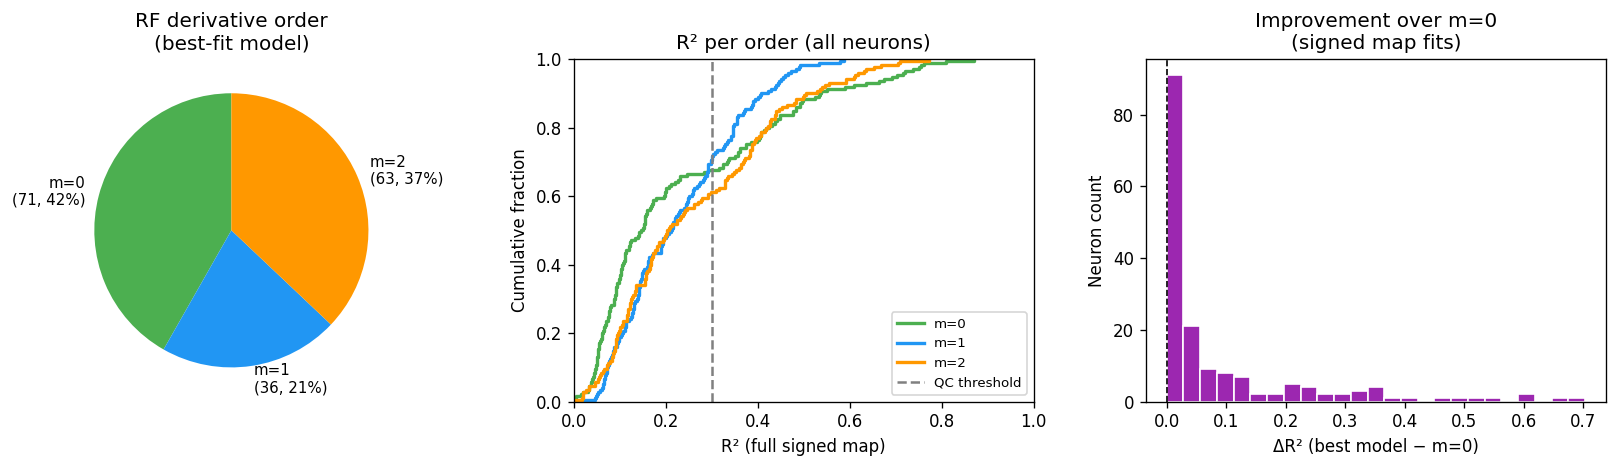

Mean ΔR²: 0.0881
Neurons with ΔR² > 0.05: 63


In [6]:
# ---------------------------------------------------------------------------
# 4.  Population distribution of derivative order
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 4a. Pie chart of best order
counts = df_order['best_m'].value_counts().sort_index()
labels = [f'm={m}\n({c}, {100*c/len(df_order):.0f}%)'
          for m, c in counts.items()]
axes[0].pie(counts.values, labels=labels,
            colors=['#4CAF50', '#2196F3', '#FF9800'],
            startangle=90, textprops={'fontsize': 9})
axes[0].set_title('RF derivative order\n(best-fit model)')

# 4b. R² for each order
for m, color in zip([0, 1, 2], ['#4CAF50', '#2196F3', '#FF9800']):
    axes[1].ecdf(df_order[f'r2_m{m}'], label=f'm={m}', color=color, lw=2)
axes[1].axvline(0.3, ls='--', color='grey', label='QC threshold')
axes[1].set_xlabel('R² (full signed map)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('R² per order (all neurons)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 1)

# 4c. ΔR² = R²(best_m) − R²(m=0)
df_order['delta_r2'] = df_order[['r2_m0', 'r2_m1', 'r2_m2']].max(axis=1) - df_order['r2_m0']
axes[2].hist(df_order['delta_r2'], bins=25, color='#9C27B0', edgecolor='white')
axes[2].axvline(0, color='black', lw=1, ls='--')
axes[2].set_xlabel('ΔR² (best model − m=0)')
axes[2].set_ylabel('Neuron count')
axes[2].set_title('Improvement over m=0\n(signed map fits)')

plt.tight_layout()
plt.savefig(nb05c_dir / 'fig_05c_order_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean ΔR²: {df_order['delta_r2'].mean():.4f}")
print(f"Neurons with ΔR² > 0.05: {(df_order['delta_r2'] > 0.05).sum()}")

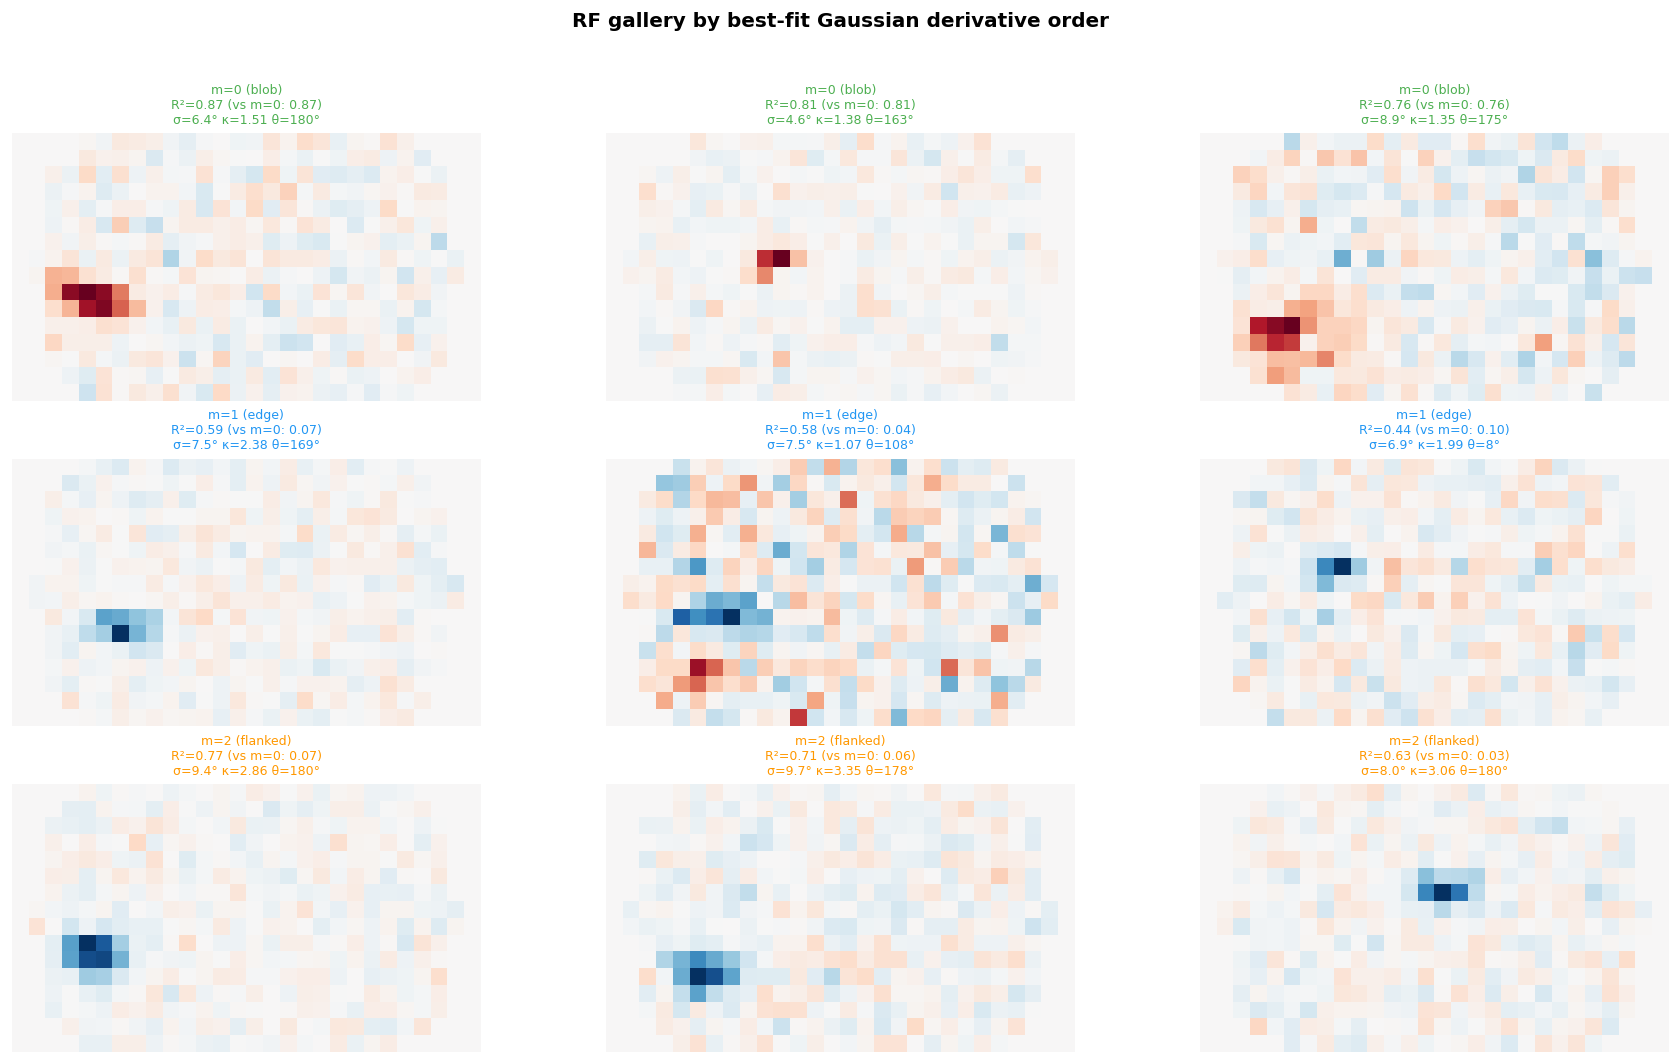

In [7]:
# ---------------------------------------------------------------------------
# 5.  Gallery: 3 representative neurons per order
# ---------------------------------------------------------------------------
N_GALLERY = 3
CMAP_RF   = 'RdBu_r'

def _model_prediction(rf_on, rf_off, m, pixel_size_deg, smooth_sigma=0.75):
    """Return the fitted model surface for order m."""
    from sparse_noise import fit_rf_by_order, _MODEL_FN
    from scipy.ndimage import gaussian_filter
    rf_signed = rf_on - rf_off
    if smooth_sigma > 0:
        rf_signed = gaussian_filter(rf_signed, sigma=smooth_sigma)
    grid_h, grid_w = rf_signed.shape
    Y, X = np.mgrid[0:grid_h, 0:grid_w]
    params, quality = fit_rf_by_order(rf_on, rf_off, m=m,
                                       pixel_size_deg=pixel_size_deg)
    # Refit with the *smoothed* map that the fitter used internally
    # (quality.aic etc are already correct; we just need the surface)
    return rf_signed, params, quality


fig = plt.figure(figsize=(15, 9))
order_labels = {0: 'm=0 (blob)', 1: 'm=1 (edge)', 2: 'm=2 (flanked)'}
order_colors = {0: '#4CAF50', 1: '#2196F3', 2: '#FF9800'}

row_offset = 0
for m_show in [0, 1, 2]:
    # Pick the N_GALLERY neurons where best_m == m_show with highest R²
    subset = [r for r in ORDER_RESULTS if r['best_m'] == m_show]
    subset.sort(key=lambda r: r['quality_best']['r_squared'], reverse=True)
    subset = subset[:N_GALLERY]

    for col_idx, rec in enumerate(subset):
        ax_idx = row_offset * N_GALLERY + col_idx + 1
        ax = fig.add_subplot(3, N_GALLERY, ax_idx)

        rf_signed = rec['rf_on'] - rec['rf_off']
        vmax = np.abs(rf_signed).max()
        ax.imshow(rf_signed, cmap=CMAP_RF, vmin=-vmax, vmax=vmax,
                  interpolation='nearest', origin='upper')

        r2_best  = rec['quality_best']['r_squared']
        r2_m0    = rec['r2_m0']
        kappa    = rec['params_best']['kappa']
        sigma    = rec['params_best']['sigma']
        theta    = rec['params_best']['theta']

        title = (f"{order_labels[m_show]}\n"
                 f"R²={r2_best:.2f} (vs m=0: {r2_m0:.2f})\n"
                 f"σ={sigma:.1f}° κ={kappa:.2f} θ={theta:.0f}°")
        ax.set_title(title, fontsize=7.5,
                     color=order_colors[m_show])
        ax.axis('off')

    row_offset += 1

fig.suptitle('RF gallery by best-fit Gaussian derivative order',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(nb05c_dir / 'fig_05c_gallery_by_order.png', dpi=150, bbox_inches='tight')
plt.show()

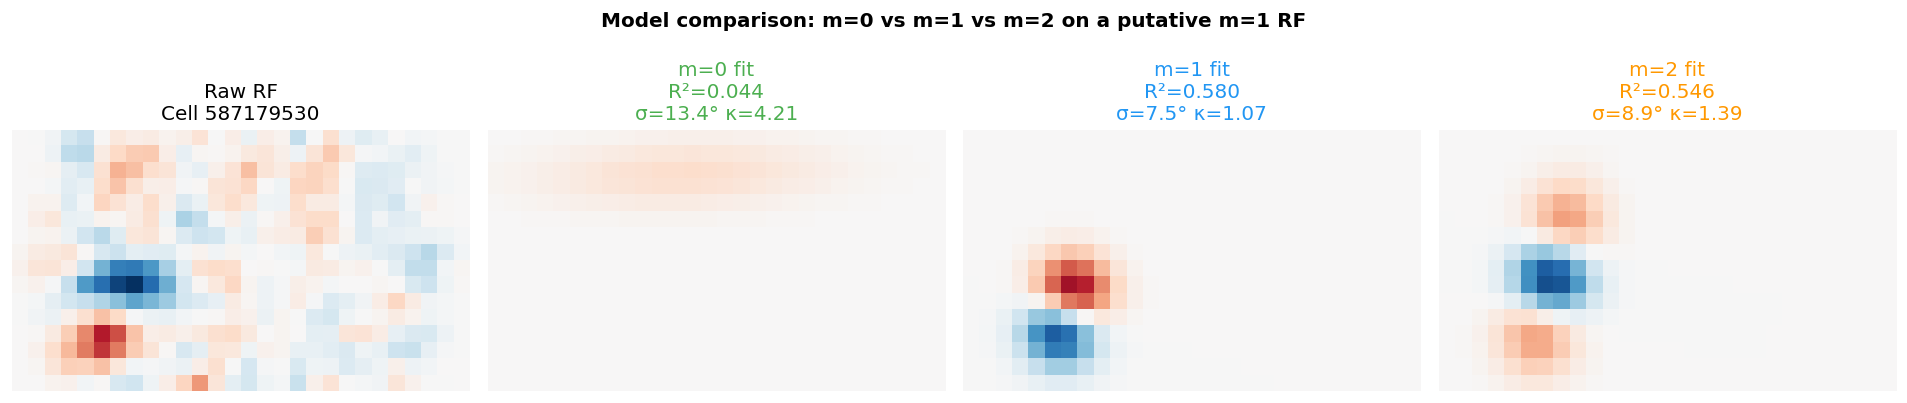

In [16]:
# ---------------------------------------------------------------------------
# 6.  Side-by-side model comparison for one m=1 neuron
#     Shows the three fits on the same RF map
# ---------------------------------------------------------------------------
# Pick the m=1 neuron with the largest ΔR² advantage over m=0
m1_neurons = [r for r in ORDER_RESULTS if r['best_m'] == 1]
m1_neurons.sort(key=lambda r: r['r2_m1'] - r['r2_m0'], reverse=True)
rec_demo = m1_neurons[0]

rf_on  = rec_demo['rf_on']
rf_off = rec_demo['rf_off']
pix = rec_demo['pix']
grid_h, grid_w = rf_on.shape
Y, X = np.mgrid[0:grid_h, 0:grid_w]
xy_data = (X.astype(float), Y.astype(float))

from scipy.ndimage import gaussian_filter as gf
rf_signed = gf(rf_on - rf_off, sigma=0.75)
vmax = np.abs(rf_signed).max()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(rf_signed, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               interpolation='nearest', origin='upper')
axes[0].set_title(f'Raw RF\nCell {rec_demo["cell_id"]}')

for col, m in enumerate([0, 1, 2], start=1):
    params, quality = fit_rf_by_order(rf_on, rf_off, m=m, pixel_size_deg=pix)
    model_fn = [gaussian_deriv_m0, gaussian_deriv_m1, gaussian_deriv_m2][m]

    # Reconstruct parameter vector for model call (pixel units)
    A     = params['amplitude']
    x0    = params['x0'] / pix
    y0    = params['y0'] / pix
    su    = params['sigma_x'] / pix
    sv    = params['sigma_y'] / pix
    theta = np.deg2rad(params['theta'])
    b     = 0.0   # absorbed into median baseline in fit; approximation

    fitted_flat = model_fn(xy_data, A, x0, y0, su, sv, theta, b)
    fitted      = fitted_flat.reshape(grid_h, grid_w)

    axes[col].imshow(fitted, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                     interpolation='nearest', origin='upper')
    axes[col].set_title(
        f'm={m} fit\n'
        f'R²={quality["r_squared"]:.3f}\n'
        f'σ={params["sigma"]:.1f}° κ={params["kappa"]:.2f}',
        color=['#4CAF50','#2196F3','#FF9800'][m]
    )

for ax in axes:
    ax.axis('off')

fig.suptitle('Model comparison: m=0 vs m=1 vs m=2 on a putative m=1 RF',
             fontweight='bold')
plt.tight_layout()
plt.savefig(nb05c_dir / 'fig_05c_model_comparison_demo.png', dpi=150, bbox_inches='tight')
plt.show()

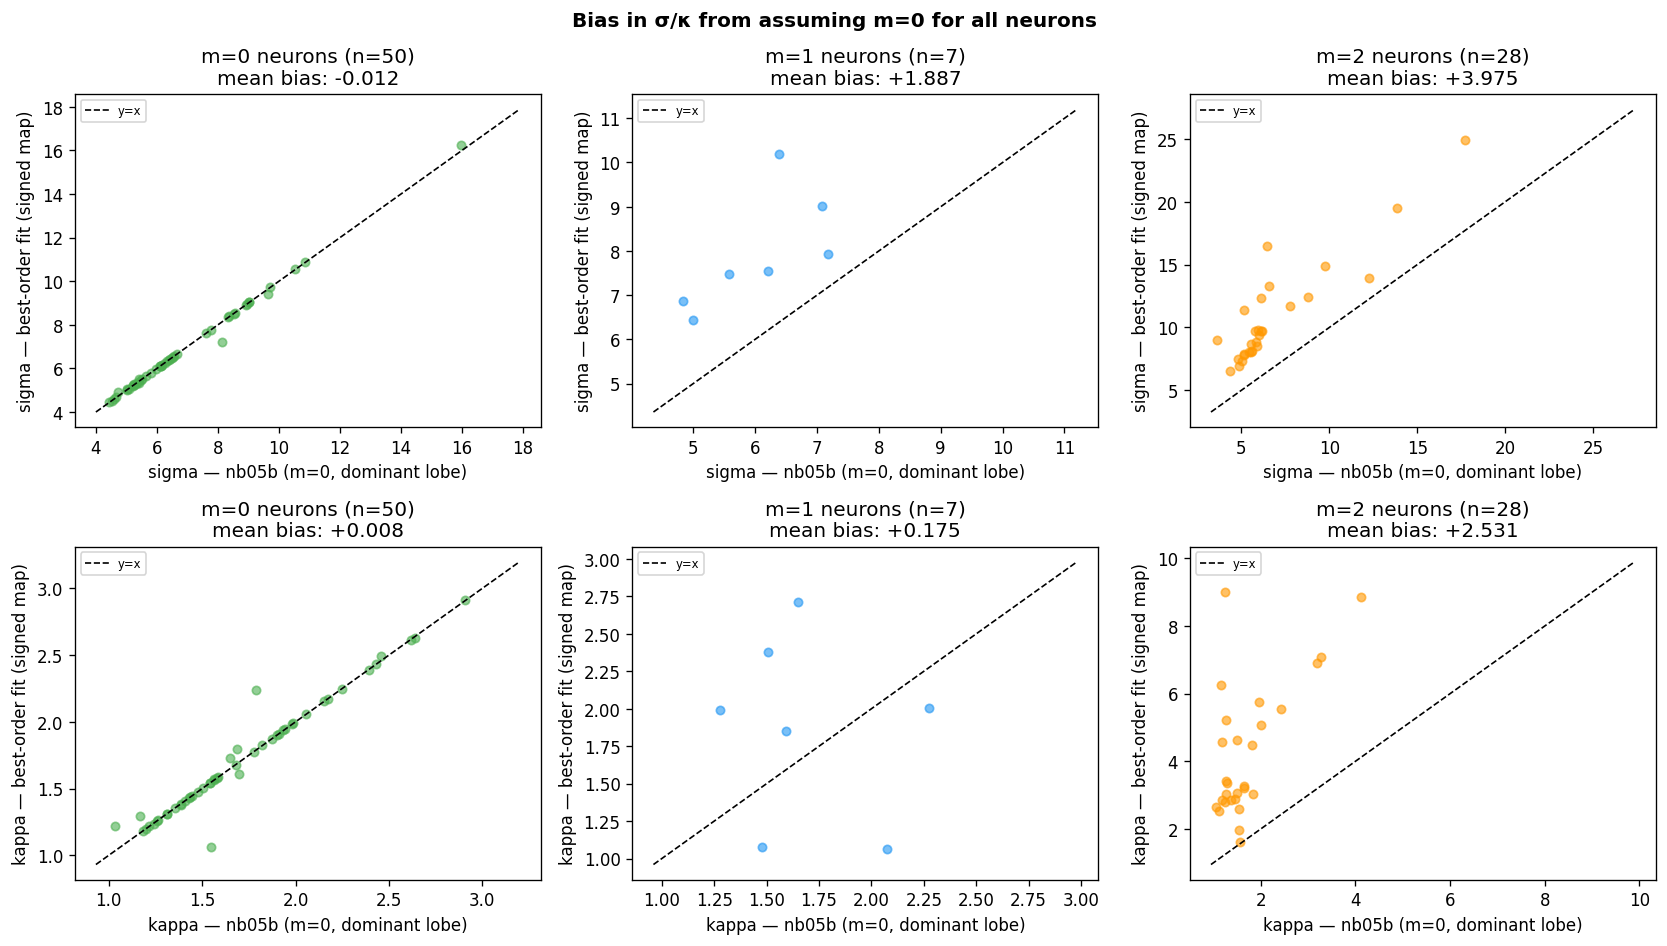


Mean bias (best_order − nb05b) by order:
        sigma_nb05b  sigma_best  kappa_nb05b  kappa_best
best_m                                                  
0             6.823       9.424        1.713       2.402
1             6.037      12.259        1.693       5.510
2             6.828      12.242        1.699       4.390


In [12]:
# ---------------------------------------------------------------------------
# 7.  Bias check: does treating m≠0 neurons as m=0 inflate σ and κ?
# ---------------------------------------------------------------------------
# sigma_nb05b and kappa_nb05b were copied directly from all_df in Cell 3,
# so no secondary join is needed.
#
# For a genuine m=1 neuron the m=0 dominant-subfield fit:
#  - anchors on ONE lobe → UNDERESTIMATES σ (one lobe < full RF envelope)
#  - OVERESTIMATES κ (single lobe appears more elongated than envelope)

bias_rows = []
for rec in ORDER_RESULTS:
    m_best = rec['best_m']
    bias_rows.append({
        'cell_id':         rec['cell_id'],
        'best_m':          m_best,
        # nb05b: m=0 fit on dominant subfield only
        'sigma_nb05b':     rec['sigma_nb05b'],
        'kappa_nb05b':     rec['kappa_nb05b'],
        # nb05c: best-order fit on full signed map
        'sigma_best':      rec['params_best']['sigma'],
        'kappa_best':      rec['params_best']['kappa'],
        # nb05c: m=0 fit on full signed map (same map, same model, no subfield)
        'sigma_m0_signed': rec['params_m0']['sigma'],
        'kappa_m0_signed': rec['params_m0']['kappa'],
    })

df_bias = pd.DataFrame(bias_rows)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row_idx, param in enumerate(['sigma', 'kappa']):
    for col_idx, m_show in enumerate([0, 1, 2]):
        ax   = axes[row_idx, col_idx]
        sub  = df_bias[df_bias['best_m'] == m_show].copy()
        if len(sub) < 3:
            ax.set_visible(False)
            continue

        nb5b_vals = sub[f'{param}_nb05b'].values
        best_vals = sub[f'{param}_best'].values
        valid     = np.isfinite(nb5b_vals) & np.isfinite(best_vals)
        nb5b_vals, best_vals = nb5b_vals[valid], best_vals[valid]

        vmin = min(nb5b_vals.min(), best_vals.min()) * 0.9
        vmax = max(nb5b_vals.max(), best_vals.max()) * 1.1
        ax.scatter(nb5b_vals, best_vals, alpha=0.6, s=25,
                   color=['#4CAF50','#2196F3','#FF9800'][m_show])
        ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1, label='y=x')
        bias = float(np.nanmean(best_vals - nb5b_vals))
        ax.set_xlabel(f'{param} — nb05b (m=0, dominant lobe)')
        ax.set_ylabel(f'{param} — best-order fit (signed map)')
        ax.set_title(f'm={m_show} neurons (n={valid.sum()})\nmean bias: {bias:+.3f}')
        ax.legend(fontsize=7)

plt.suptitle('Bias in σ/κ from assuming m=0 for all neurons', fontweight='bold')
plt.tight_layout()
plt.savefig(nb05c_dir / 'fig_05c_bias_check.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean bias (best_order − nb05b) by order:')
print(df_bias.groupby('best_m')[[
    'sigma_nb05b','sigma_best','kappa_nb05b','kappa_best'
]].mean().round(3))

In [13]:
# ---------------------------------------------------------------------------
# 8.  Summary table and implication for the main analysis
# ---------------------------------------------------------------------------
summary = df_order.groupby('best_m').agg(
    n=('cell_id', 'count'),
    r2_best_mean=(f'r2_m0', 'mean'),   # placeholder; compute from best below
).copy()

# Compute mean R² of the best-fit model per order
for m_show in [0, 1, 2]:
    idx = df_order['best_m'] == m_show
    summary.loc[m_show, 'r2_best_mean'] = df_order.loc[idx, f'r2_m{m_show}'].mean()
    summary.loc[m_show, 'r2_m0_mean']   = df_order.loc[idx, 'r2_m0'].mean()
    summary.loc[m_show, 'delta_r2_mean']= (
        df_order.loc[idx, f'r2_m{m_show}'] -
        df_order.loc[idx, 'r2_m0']
    ).mean()

print('\n=== Order classification summary ===')
print(summary.to_string(float_format='{:.3f}'.format))

print("""
=== Implications for main analysis ===

1.  The fraction of m≠0 neurons quantifies how many RFs in the population
    have genuine antisymmetric (m=1) or second-order (m=2) structure.

2.  For these neurons the nb05b pipeline (m=0 dominant-subfield fit)
    UNDERESTIMATES σ (fits one lobe, not the envelope) and may
    OVERESTIMATE κ (single lobe appears more elongated than the envelope).
    The bias check in Cell 7 quantifies the direction and magnitude.

3.  If m≠0 neurons are a minority (<20%) AND the bias in σ/κ is small,
    the main analysis conclusions (σ-κ coupling, no spatial gradient) are
    robust.  If m≠0 neurons are numerous or the bias is large, we should
    re-run the population fits using the best-order model per neuron.

4.  This classification also provides the first empirical characterisation
    of the Lindeberg derivative-order distribution in mouse V1 — a result
    Lindeberg has asked about and that does not appear in the literature.
""")


=== Order classification summary ===
         n  r2_best_mean  r2_m0_mean  delta_r2_mean
best_m                                             
0       71         0.415       0.415          0.000
1       36         0.218       0.096          0.123
2       63         0.278       0.110          0.168

=== Implications for main analysis ===

1.  The fraction of m≠0 neurons quantifies how many RFs in the population
    have genuine antisymmetric (m=1) or second-order (m=2) structure.

2.  For these neurons the nb05b pipeline (m=0 dominant-subfield fit)
    UNDERESTIMATES σ (fits one lobe, not the envelope) and may
    OVERESTIMATE κ (single lobe appears more elongated than the envelope).
    The bias check in Cell 7 quantifies the direction and magnitude.

3.  If m≠0 neurons are a minority (<20%) AND the bias in σ/κ is small,
    the main analysis conclusions (σ-κ coupling, no spatial gradient) are
    robust.  If m≠0 neurons are numerous or the bias is large, we should
    re-run the popula

In [15]:
# ---------------------------------------------------------------------------
# Optional: Save order classification for downstream use
# ---------------------------------------------------------------------------
# Tabular results (no RF maps)
df_order.to_csv('data/nb05c_order_classification.csv', index=False)
print('Saved nb05c_order_classification.csv')

Saved nb05c_order_classification.csv
